In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from itertools import combinations
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   
from clustergram import Clustergram





# duomenu ikelimas
data = pd.read_csv("CC GENERAL.csv")
data = data.drop('CUST_ID', axis=1)
data.head()



#  pradinė statistika (parodyti trūkstamas reikšmes, kardinalumą ir t. t.)
con_stats = []
for feature in data.columns:
    stat = {
        'Feature': feature,
        'Amount': len(data[feature]),
        'Missing %': (data[feature].isna().sum() / len(data[feature])) * 100,
        'Cardinality': data[feature].nunique(),
        'Max value': data[feature].max(),
        'Min value': data[feature].min(),
        'First quartile': data[feature].quantile(0.25),
        'Third quartile': data[feature].quantile(0.75),
        'Mean': data[feature].mean(),
        'Median': data[feature].median(),
        'Standard deviation': data[feature].std()
    }
    con_stats.append(stat)

con_stats_df = pd.DataFrame(con_stats).set_index('Feature')
con_stats_df



#  trūkstamų reikšmių ir kategorinių/„frequency" kintamųjų šalinimas
data = data.dropna()
data = data.drop(['BALANCE_FREQUENCY',
                  'PURCHASES_FREQUENCY',
                  'ONEOFF_PURCHASES_FREQUENCY',
                  'PURCHASES_INSTALLMENTS_FREQUENCY',
                  'PRC_FULL_PAYMENT',
                  'TENURE'], axis=1)



# ekstremalių reikšmių šalinimas (IQR), tik tolydinių (≥50 kategorijų) atranka ir standartizavimas
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
data_clean = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

continuous_cols = [col for col in data_clean.columns if data_clean[col].nunique() >= 50]
data_cont = data_clean[continuous_cols]

scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_cont), columns=continuous_cols)
data_scaled.head()


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,-0.805690,-0.699902,-0.604747,-0.382513,-0.561305,-0.897822,-0.822601,-0.651558
1,1.634862,0.800192,1.607593,-0.729293,-0.561305,1.679603,-0.236043,0.803874
2,-0.033211,-0.875636,-0.558965,-0.729293,-0.561305,-0.818517,-0.157510,-0.337418
3,0.967113,0.054384,-0.604747,0.856295,-0.561305,-0.382337,-0.156491,0.519663
4,0.162900,0.995669,1.288033,-0.002292,-0.561305,1.481339,-0.143632,-0.136988


In [2]:
def winnerMc(x, weights):
    """KONKURENCIJA. Randa BMU (Best Matching Unit) m_c — artimiausią mazgą
       pagal Euklido atstumą:   c(x) = argmin_i || x - w_i ||"""
    dists = np.linalg.norm(weights - x, axis=1)      # Euklido atstumas iki kiekvieno mazgo
    return int(np.argmin(dists))

def radius(t, T, sigma0):
    """Kaimynystės SPINDULYS sigma(t). Iš pradžių didelis (apima daug kaimynų),
       su kiekviena iteracija mažėja eksponentiškai:
            sigma(t) = sigma0 * exp(-t / lambda),   lambda = T / ln(sigma0)"""
    lam = T / np.log(sigma0) if sigma0 > 1 else T
    return sigma0 * np.exp(-t / lam)

def learning_rate(t, T, alpha0):
    """Mokymosi greitis alpha(t) ∈ (0, 1]. Mažėja eksponentiškai:
            alpha(t) = alpha0 * exp(-t / T)"""
    return alpha0 * np.exp(-t / T)

def neighbourhood(c, k, sigma):
    """Gauso kaimynystės (BRANDUOLIO) funkcija h_{i,c}  — formulė (8.16).
       1D gardelėje atstumas tarp mazgų i ir c (= BMU) yra |i - c|:
            h_{i,c} = exp( -|i - c|^2 / (2 * sigma^2) )
       Pirmosios eilės kaimynai: |i-c|=1, antrosios: |i-c|=2, ..."""
    idx = np.arange(k)
    return np.exp(-((idx - c) ** 2) / (2.0 * sigma ** 2))

def rewardNeighbours(x, weights, c, alpha, sigma):
    """PRITAIKYMAS — kaimynų 'apdovanojimas', formulė (8.15).
       BMU ir jo kaimynai pastumiami link x; kuo arčiau BMU (didesnis h),
       tuo labiau keičiami svoriai (stipresnis ryšys):
            w_i <- w_i + alpha * h_{i,c} * (x - w_i)         (visiems i)"""
    k = weights.shape[0]
    h = neighbourhood(c, k, sigma)                   # (k,) — ryšio stiprumas kiekvienam mazgui
    weights += (alpha * h)[:, None] * (x - weights)  # in-place atnaujinimas
    return weights


def SOM(X, k, n_iter=1, alpha0=0.5, random_state=42):
    """1D SOM su k mazgų (= k klasterių).
       n_iter — iteracijų skaičius (rekom. 1000–8000).
       Grąžina: weights (k×d) ir labels (n,) — kiekvieno taško klasteris."""
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    # --- Svorių INICIALIZACIJA: k atsitiktinai parinktų duomenų taškų ---
    weights = X[rng.choice(n, size=k, replace=False)].copy()
    sigma0 = max(1.0, k / 2.0)                        # pradinis spindulys ≈ pusė gardelės
    # --- MOKYMAS (online) ---
    for t in range(n_iter):
        x = X[rng.integers(n)]                        # atsitiktinis imties elementas
        c = winnerMc(x, weights)                      # konkurencija (BMU)
        a = learning_rate(t, n_iter, alpha0)
        s = radius(t, n_iter, sigma0)
        rewardNeighbours(x, weights, c, a, s)    
    # --- Klasterių ŽYMĖS = kiekvieno taško BMU ---
    dists = np.linalg.norm(X[:, None, :] - weights[None, :, :], axis=2)   # (n, k)
    labels = np.argmin(dists, axis=1)
    return weights, labels        


In [3]:
def inertia(X, weights, labels):
    """INERCIJA = SOM kvantavimo PAKLAIDA  E_Q = Σ_j || x_j - w_{BMU(j)} ||^2.
       Tai suma kvadratinių atstumų nuo kiekvieno taško iki jo klasterio centro
       (čia centras = BMU mazgo svorių vektorius).
       Maža inercija → taškai arti savo centrų → 'tankūs' klasteriai.
       Visada mažėja didinant k → naudojama 'alkūnės' (elbow) metodui."""
    X = np.asarray(X, dtype=float)
    return float(np.sum(np.linalg.norm(X - weights[labels], axis=1) ** 2))


def silhouette(X, labels):
    """SILUETO KOEFICIENTAS ∈ [-1, 1]. Kiekvienam taškui:
            s = (b - a) / max(a, b)
       a = vid. atstumas iki SAVO klasterio taškų (kohezija),
       b = vid. atstumas iki artimiausio KITO klasterio taškų (separacija).
       Visumos siluetas = visų taškų s vidurkis.
        s ≈  1  → gerai atskirti, tankūs klasteriai
        s ≈  0  → taškai ant klasterių ribos
        s <  0  → taškai greičiausiai priskirti blogam klasteriui
       Reikia ≥ 2 unikalių žymių (kitaip neapibrėžtas)."""
    if len(np.unique(labels)) < 2:
        return np.nan
    return float(silhouette_score(X, labels))

In [4]:
continuous_cols = list(data_scaled.columns)     # 8 tolydiniai atributai
k_values = range(2, 9)                            # k = 2..8

records = []   # po vieną įrašą kiekvienai (pora, k) kombinacijai

# --- 1-as ciklas: visos C(8,2) = 28 atributų poros ---
for col1, col2 in combinations(continuous_cols, 2):
    Xpair = data_scaled[[col1, col2]].values
    # --- 2-as ciklas: k = 2..8 ---
    for k in k_values:
        w, labels = SOM(Xpair, k=k, n_iter=5, random_state=42)
        records.append({
            'col1': col1, 'col2': col2, 'k': k,
            'inertia':    inertia(Xpair, w, labels),
            'silhouette': silhouette(Xpair, labels),
        })

res = pd.DataFrame(records)







# --- visos C(8,2) = 28 atributų poros --- 8x7 / 2 = 28 porų

# --- Kiekvienai porai randame jos GERIAUSIĄ rezultatą (didžiausią siluetą per k=2..8) ---
best_rows = []   # po vieną įrašą kiekvienai porai

for (col1, col2), group in res.groupby(['col1', 'col2']):
    # 'group' = visos 7 eilutės šitai porai (k=2,3,...,8)
    group = group.dropna(subset=['silhouette'])
    if group.empty:
        continue
    # imame eilutę su DIDŽIAUSIU silueto koeficientu
    best_k_row = group.loc[group['silhouette'].idxmax()]
    best_rows.append(best_k_row)

best_per_pair = pd.DataFrame(best_rows)

# surūšiuojame poras mažėjimo tvarka pagal didžiausią siluetą
best_per_pair = best_per_pair.sort_values('silhouette', ascending=False).reset_index(drop=True).head(20)

best_per_pair      # viršuje – geriausia pora ir prie kokio k tai pasiekta


,col1,col2,k,inertia,silhouette
0,BALANCE,MINIMUM_PAYMENTS,2,5026.484773,0.639526
1,PURCHASES,ONEOFF_PURCHASES,2,6317.211938,0.551130
2,CASH_ADVANCE,MINIMUM_PAYMENTS,2,7191.396508,0.539265
3,ONEOFF_PURCHASES,CASH_ADVANCE,4,6526.548196,0.535376
4,PURCHASES,INSTALLMENTS_PURCHASES,2,6239.442851,0.518331
5,ONEOFF_PURCHASES,MINIMUM_PAYMENTS,2,6968.059295,0.500693
6,BALANCE,CASH_ADVANCE,5,5567.873961,0.496771
7,INSTALLMENTS_PURCHASES,MINIMUM_PAYMENTS,2,7193.382036,0.486096
8,CASH_ADVANCE,PAYMENTS,4,8900.081287,0.485480
9,CREDIT_LIMIT,MINIMUM_PAYMENTS,2,8110.663438,0.480000


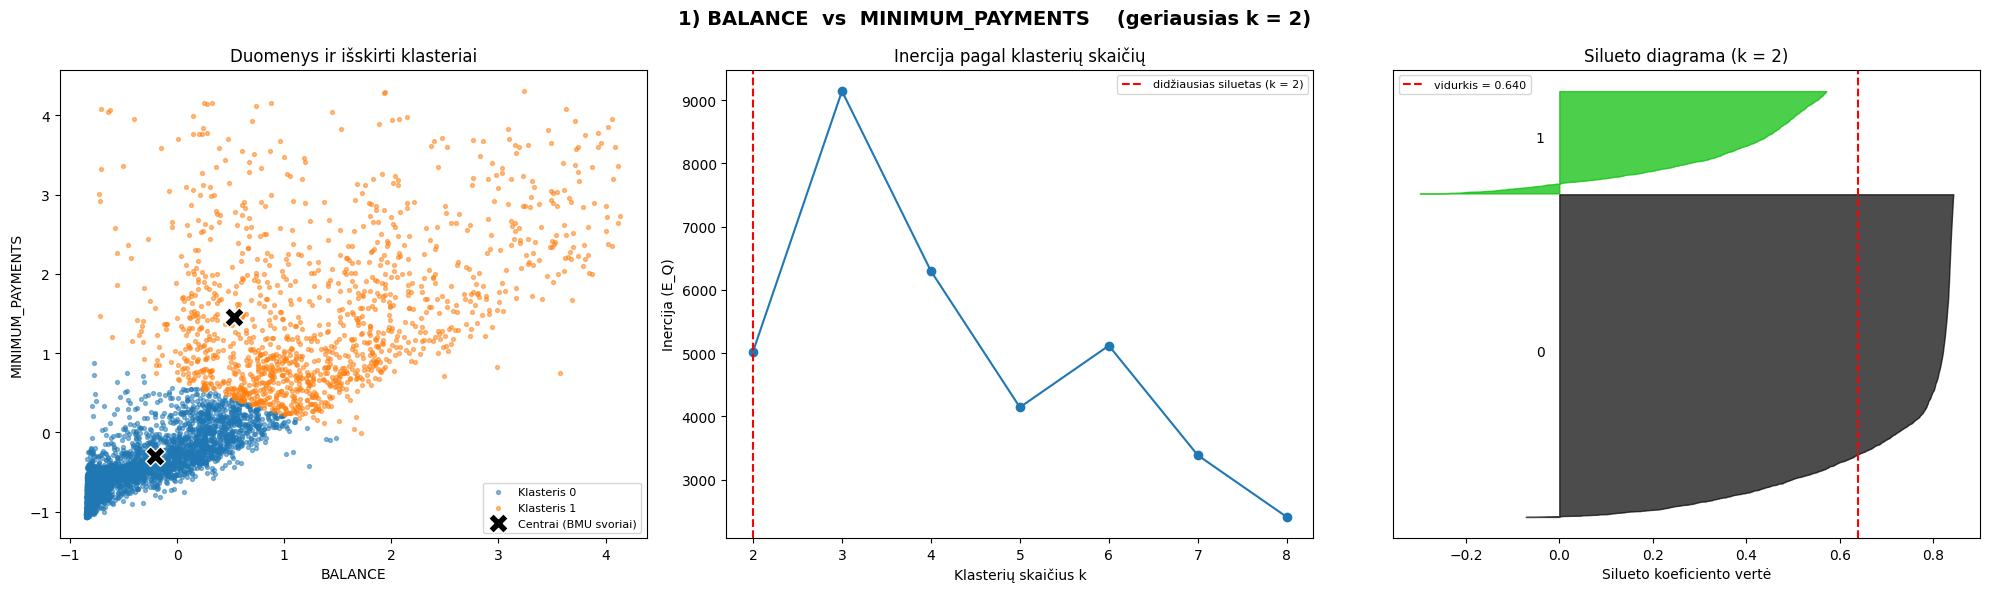

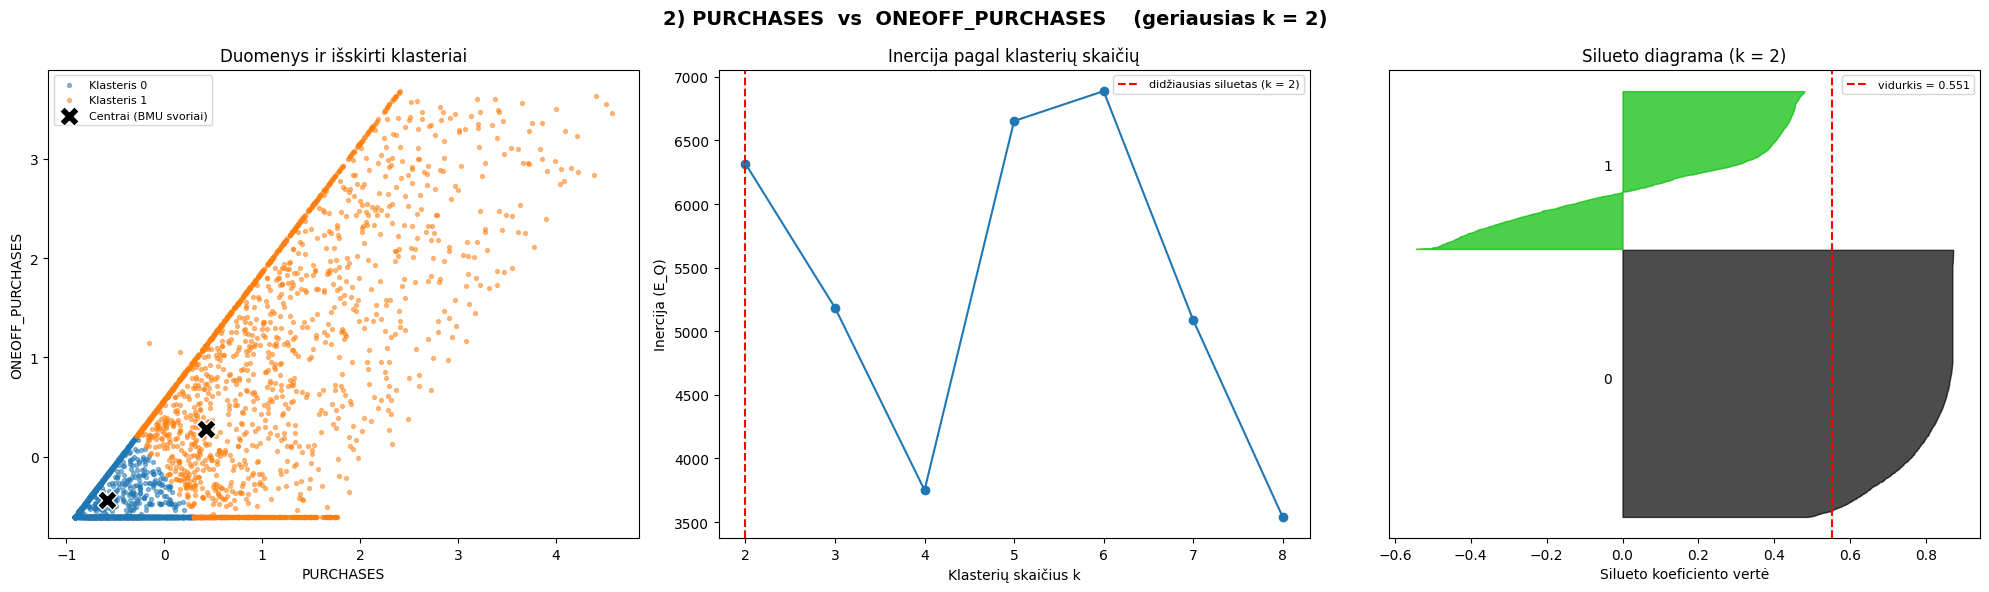

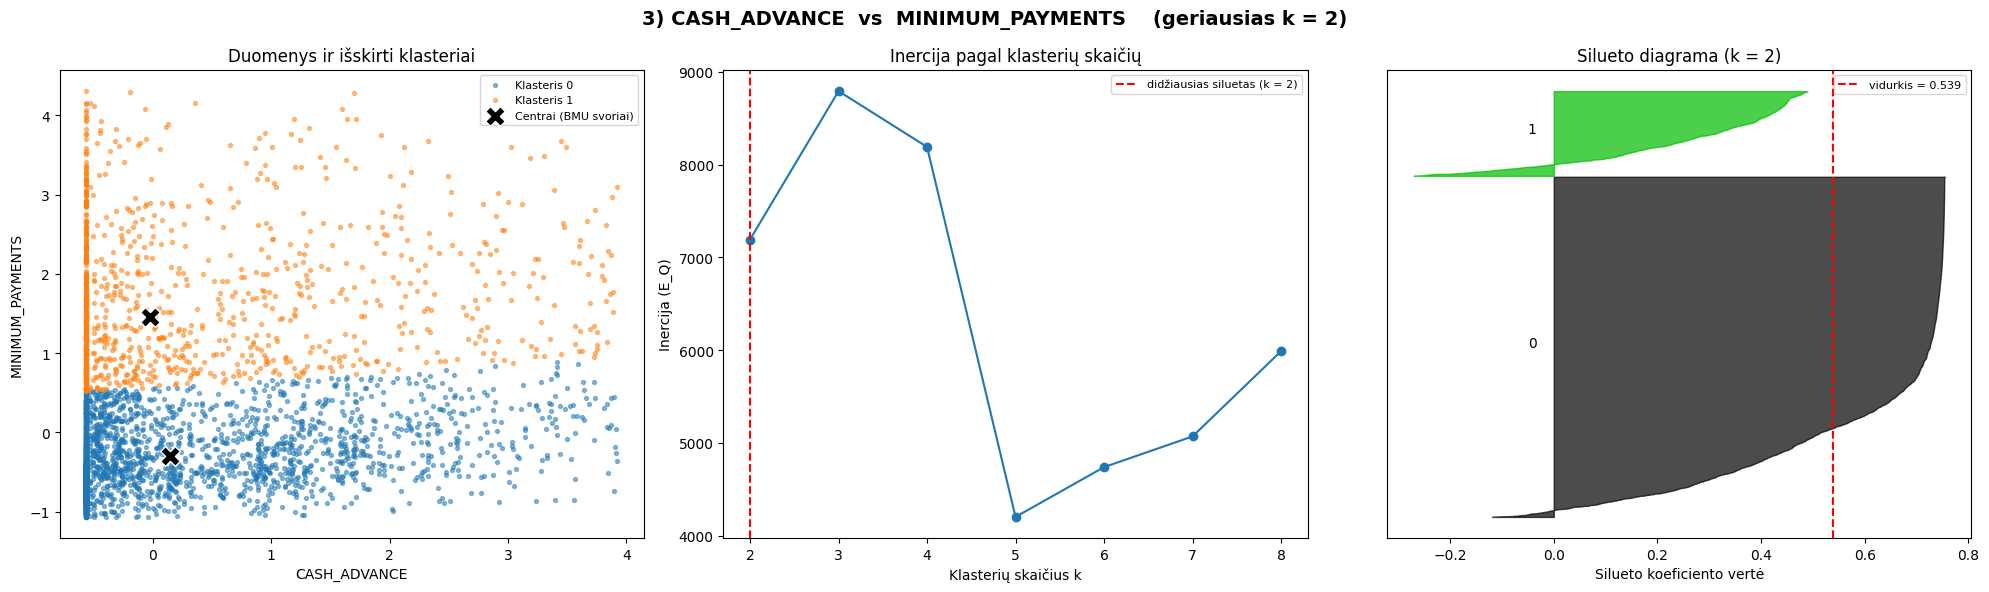

In [5]:
best_three_results = best_per_pair.head(3).reset_index(drop=True)

for i in best_three_results.index:
    col1 = best_three_results.loc[i, 'col1']
    col2 = best_three_results.loc[i, 'col2']
    k = int(best_three_results.loc[i, 'k'])
    Xpair = data_scaled[[col1, col2]].values
    w, labels = SOM(Xpair, k=k, n_iter=5, random_state=42)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"{i+1}) {col1}  vs  {col2}    (geriausias k = {k})", fontsize=14, fontweight='bold')

    # 1) DUOMENŲ grafikas XOY su išskirtais klasteriais
    for cl in np.unique(labels):
        m = labels == cl
        ax1.scatter(Xpair[m, 0], Xpair[m, 1], s=8, alpha=0.5, label=f'Klasteris {cl}')
    ax1.scatter(w[:, 0], w[:, 1], c='black', marker='X', s=200, edgecolor='white', label='Centrai (BMU svoriai)')
    ax1.set_xlabel(col1)
    ax1.set_ylabel(col2)
    ax1.set_title('Duomenys ir išskirti klasteriai')
    ax1.legend(fontsize=8)

    # 2) INERCIJOS grafikas (OX = klasterių sk. k, OY = inercija) tai pačiai porai
    sub = res[(res['col1'] == col1) & (res['col2'] == col2)].sort_values('k')
    ax2.plot(sub['k'], sub['inertia'], marker='o')
    ax2.axvline(k, color='red', linestyle='--', label=f'didžiausias siluetas (k = {k})')
    ax2.set_xlabel('Klasterių skaičius k')
    ax2.set_ylabel('Inercija (E_Q)')
    ax2.set_title('Inercija pagal klasterių skaičių')
    ax2.legend(fontsize=8)

    # 3) SILUETO diagrama pagal geriausią k
    sil_avg    = silhouette_score(Xpair, labels)
    sample_sil = silhouette_samples(Xpair, labels)
    y_lower = 10
    for cl in range(k):
        vals = np.sort(sample_sil[labels == cl])
        y_upper = y_lower + len(vals)
        color = plt.cm.nipy_spectral(float(cl) / k)
        ax3.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax3.text(-0.05, y_lower + 0.5 * len(vals), str(cl))
        y_lower = y_upper + 10
    ax3.axvline(sil_avg, color='red', linestyle='--', label=f'vidurkis = {sil_avg:.3f}')
    ax3.set_xlabel('Silueto koeficiento vertė')
    ax3.set_yticks([])
    ax3.set_title(f'Silueto diagrama (k = {k})')
    ax3.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [6]:
# Rasti geriausiai į klasterius atskiriančius duomenų atributų trejetus. Šis uždavinys analogiškas 2 uždaviniui, tik reikia patikrinti  C_m^3 trejetus. Šiame uždavinyje taip pat reikia užpildyti lentelę ir pateikti 9 grafikus (3D grafikai duomenų atvaizdavimui, o 2D grafikai inercijos ir silueto diagramoms).

continuous_cols = list(data_scaled.columns)     # 8 tolydiniai atributai
k_values = range(2, 9)                            # k = 2..8

records = []

# --- 1-as ciklas: visi C(8,3) = 56 atributų TREJETAI ---         
for col1, col2, col3 in combinations(continuous_cols, 3):       
    Xtri = data_scaled[[col1, col2, col3]].values               
    # --- 2-as ciklas: k = 2..8 ---
    for k in k_values:
        w, labels = SOM(Xtri, k=k, n_iter=5, random_state=42) 
        records.append({
            'col1': col1, 'col2': col2, 'col3': col3, 'k': k, 
            'inertia':    inertia(Xtri, w, labels),
            'silhouette': silhouette(Xtri, labels),
        })

res = pd.DataFrame(records)




# --- C(8,3) = 56 trejetai --- 8·7·6 / (3·2·1) = 56

# --- Kiekvienam trejetui randame jo GERIAUSIĄ rezultatą (didžiausią siluetą per k=2..8) ---
best_rows = []

for (col1, col2, col3), group in res.groupby(['col1', 'col2', 'col3']):   
    group = group.dropna(subset=['silhouette'])
    if group.empty:
        continue
    best_k_row = group.loc[group['silhouette'].idxmax()]
    best_rows.append(best_k_row)

best_per_triple = pd.DataFrame(best_rows)        

best_per_triple = best_per_triple.sort_values('silhouette', ascending=False).reset_index(drop=True).head(20)

best_per_triple      # viršuje – geriausias trejetas ir prie kokio k tai pasiekta

,col1,col2,col3,k,inertia,silhouette
0,BALANCE,CASH_ADVANCE,MINIMUM_PAYMENTS,2,10632.443457,0.528106
1,BALANCE,ONEOFF_PURCHASES,MINIMUM_PAYMENTS,2,10381.913842,0.493948
2,BALANCE,INSTALLMENTS_PURCHASES,MINIMUM_PAYMENTS,2,10685.352430,0.484273
3,BALANCE,PAYMENTS,MINIMUM_PAYMENTS,2,10826.460838,0.483574
4,BALANCE,PURCHASES,MINIMUM_PAYMENTS,2,10438.741102,0.483528
5,BALANCE,CREDIT_LIMIT,MINIMUM_PAYMENTS,2,11522.058865,0.483076
6,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,2,10368.299483,0.482128
7,PURCHASES,ONEOFF_PURCHASES,PAYMENTS,2,10754.332928,0.443021
8,BALANCE,CASH_ADVANCE,PAYMENTS,4,15943.387355,0.441640
9,ONEOFF_PURCHASES,CASH_ADVANCE,PAYMENTS,5,9685.580279,0.431461


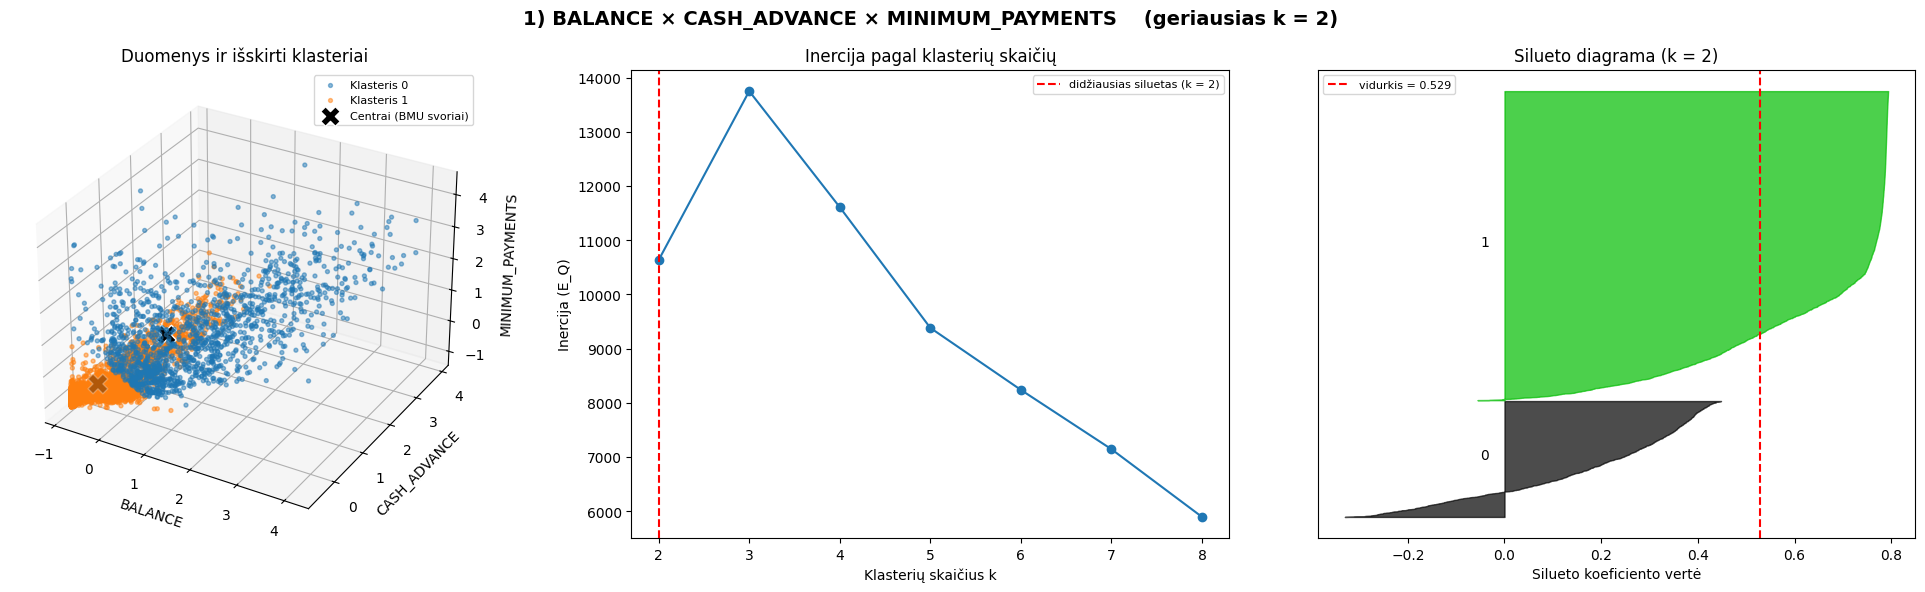

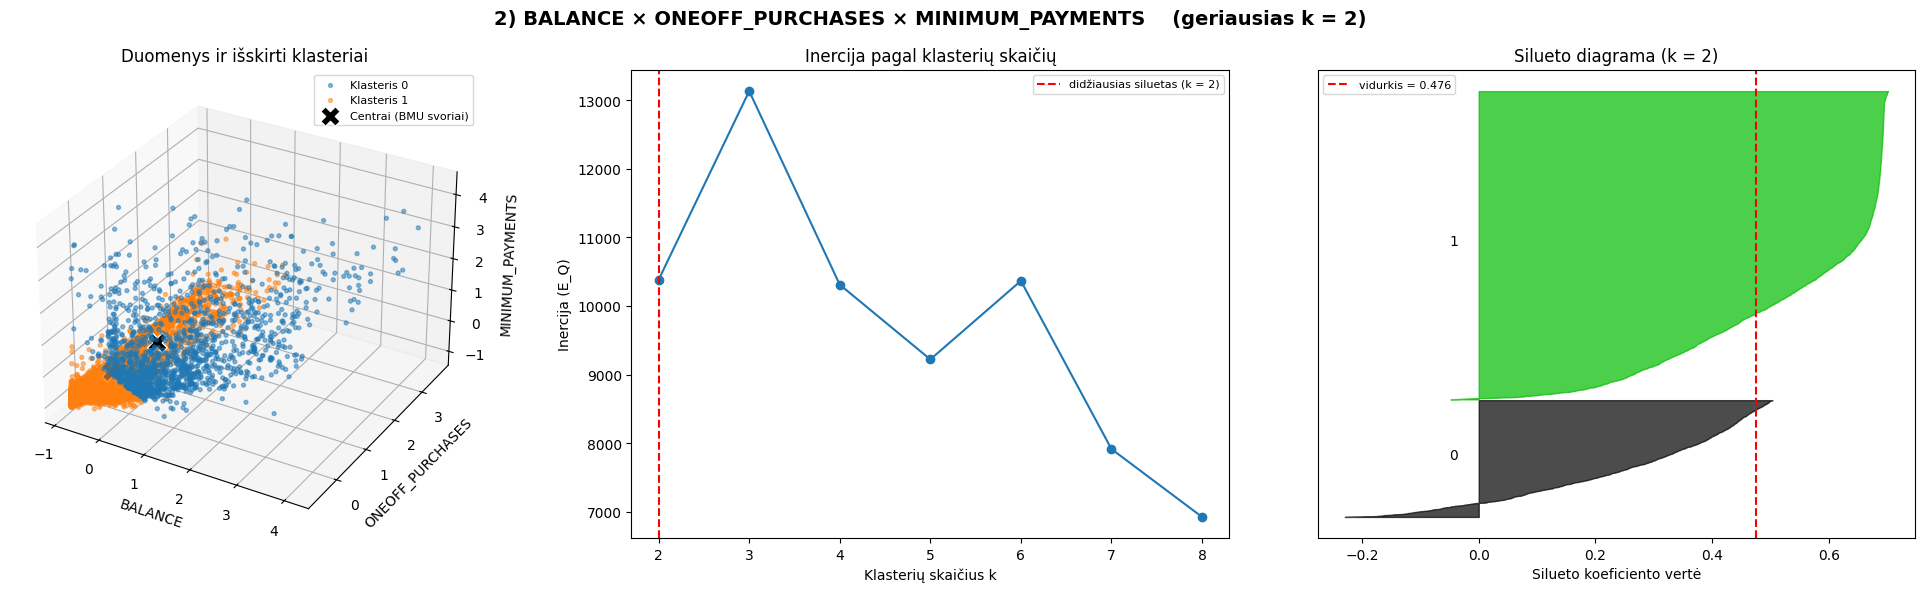

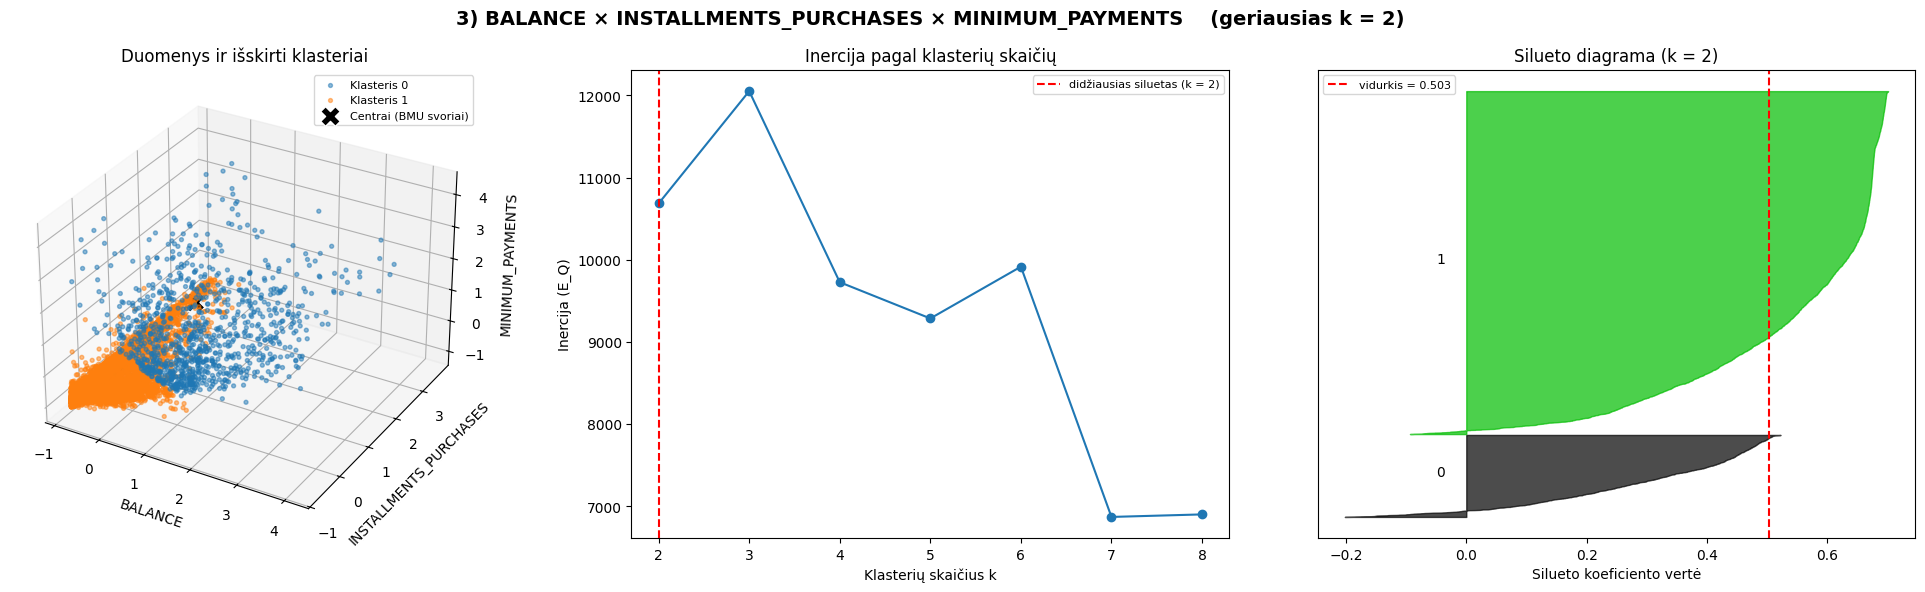

In [7]:
best_three_triples = best_per_triple.head(3).reset_index(drop=True)

for i in best_three_triples.index:
    col1 = best_three_triples.loc[i, 'col1']
    col2 = best_three_triples.loc[i, 'col2']
    col3 = best_three_triples.loc[i, 'col3']
    k    = int(best_three_triples.loc[i, 'k'])
    Xtri = data_scaled[[col1, col2, col3]].values
    w, labels = SOM(Xtri, k=k, n_iter=5000, random_state=42)

    # --- figūrą kuriam per add_subplot, kad 1-as grafikas galėtų būti 3D ---
    fig = plt.figure(figsize=(20, 6))
    fig.suptitle(f"{i+1}) {col1} × {col2} × {col3}    (geriausias k = {k})", fontsize=14, fontweight='bold')
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')   # <-- 3D
    ax2 = fig.add_subplot(1, 3, 2)                     # 2D
    ax3 = fig.add_subplot(1, 3, 3)                     # 2D

    # 1) DUOMENŲ grafikas 3D su išskirtais klasteriais
    for cl in np.unique(labels):
        m = labels == cl
        ax1.scatter(Xtri[m, 0], Xtri[m, 1], Xtri[m, 2], s=8, alpha=0.5, label=f'Klasteris {cl}')
    ax1.scatter(w[:, 0], w[:, 1], w[:, 2], c='black', marker='X', s=200, edgecolor='white', label='Centrai (BMU svoriai)')
    ax1.set_xlabel(col1)
    ax1.set_ylabel(col2)
    ax1.set_zlabel(col3)
    ax1.set_title('Duomenys ir išskirti klasteriai')
    ax1.legend(fontsize=8)

    # 2) INERCIJOS grafikas (OX = klasterių sk. k, OY = inercija) tam pačiam trejetui
    sub = res[(res['col1'] == col1) & (res['col2'] == col2) & (res['col3'] == col3)].sort_values('k')
    ax2.plot(sub['k'], sub['inertia'], marker='o')
    ax2.axvline(k, color='red', linestyle='--', label=f'didžiausias siluetas (k = {k})')
    ax2.set_xlabel('Klasterių skaičius k')
    ax2.set_ylabel('Inercija (E_Q)')
    ax2.set_title('Inercija pagal klasterių skaičių')
    ax2.legend(fontsize=8)

    # 3) SILUETO diagrama pagal geriausią k
    sil_avg    = silhouette_score(Xtri, labels)
    sample_sil = silhouette_samples(Xtri, labels)
    y_lower = 10
    for cl in range(k):
        vals = np.sort(sample_sil[labels == cl])
        y_upper = y_lower + len(vals)
        color = plt.cm.nipy_spectral(float(cl) / k)
        ax3.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax3.text(-0.05, y_lower + 0.5 * len(vals), str(cl))
        y_lower = y_upper + 10
    ax3.axvline(sil_avg, color='red', linestyle='--', label=f'vidurkis = {sil_avg:.3f}')
    ax3.set_xlabel('Silueto koeficiento vertė')
    ax3.set_yticks([])
    ax3.set_title(f'Silueto diagrama (k = {k})')
    ax3.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


In [9]:
continuous_cols = list(data_scaled.columns)     # 8 tolydiniai atributai
k_values = range(2, 9)                            # k = 2..8

X = data_scaled.values                            # visa m = 8 dimensijų erdvė (visi stulpeliai)

records = []
# --- vienas ciklas: k = 2..8 (jokių atributų kombinacijų — naudojam visus 8) ---
for k in k_values:
    w, labels = SOM(X, k=k, n_iter=5000, random_state=42)   # SOM nekeičiamas, čia tiesiog d=8
    records.append({
        'k': k,
        'inertia':    inertia(X, w, labels),
        'silhouette': silhouette(X, labels),
    })

res_mdim = pd.DataFrame(records)
res_mdim

# --- Apibendrinanti lentelė: k=2..8 stulpeliuose, Inercija ir Silueto koef. eilutėse ---
table_mdim = res_mdim.set_index('k')[['inertia', 'silhouette']].T
table_mdim.index = ['Inercija', 'Silueto koef.']
table_mdim.columns = [f'k={c}' for c in table_mdim.columns]
table_mdim

,k=2,k=3,k=4,k=5,k=6,k=7,k=8
Inercija,36802.551703,35967.562635,32855.282768,30026.049608,27518.569562,26154.285932,25426.556617
Silueto koef.,0.301258,0.078324,0.101188,0.073522,0.084946,0.073939,0.089166


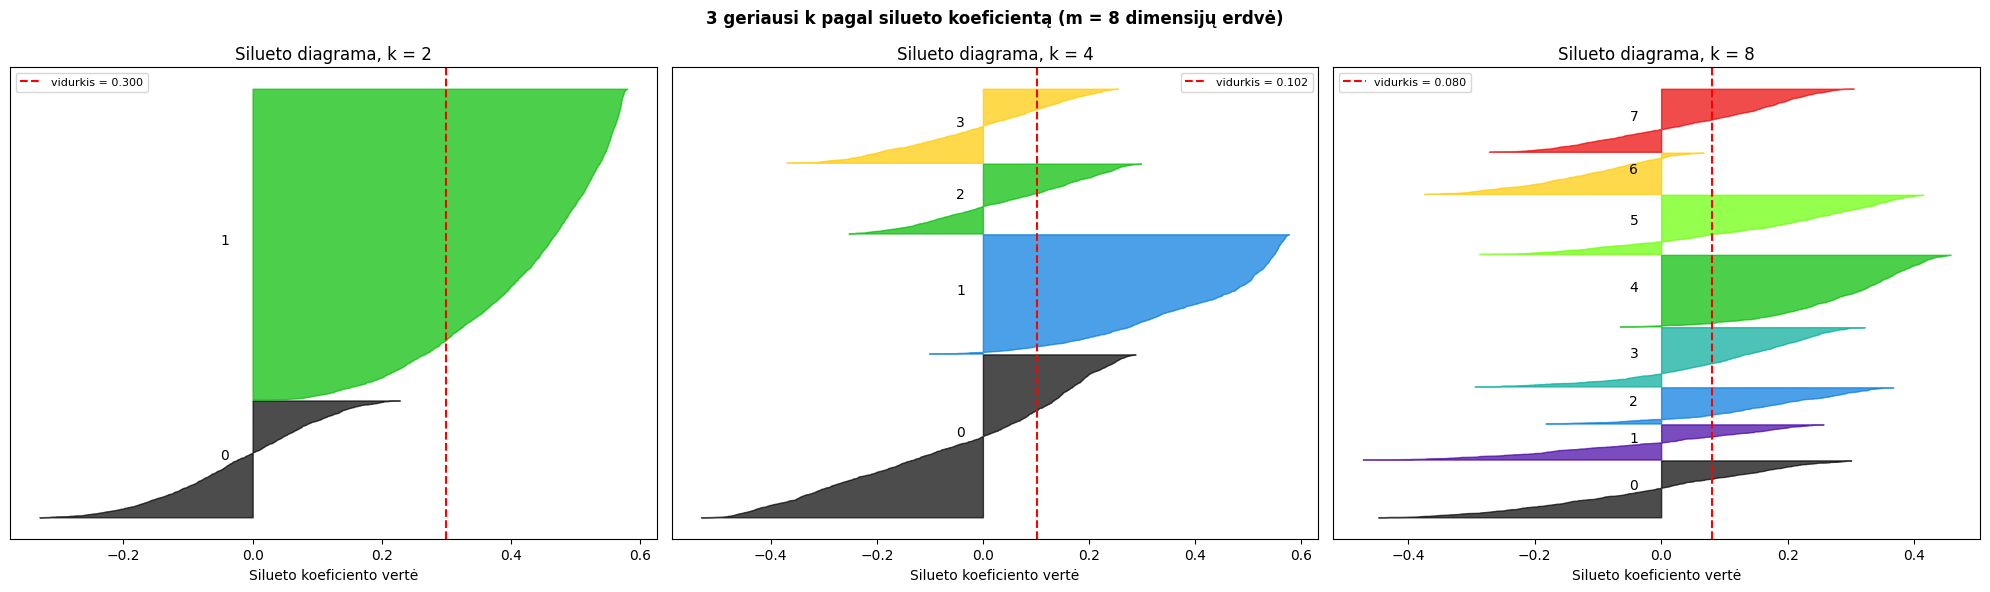

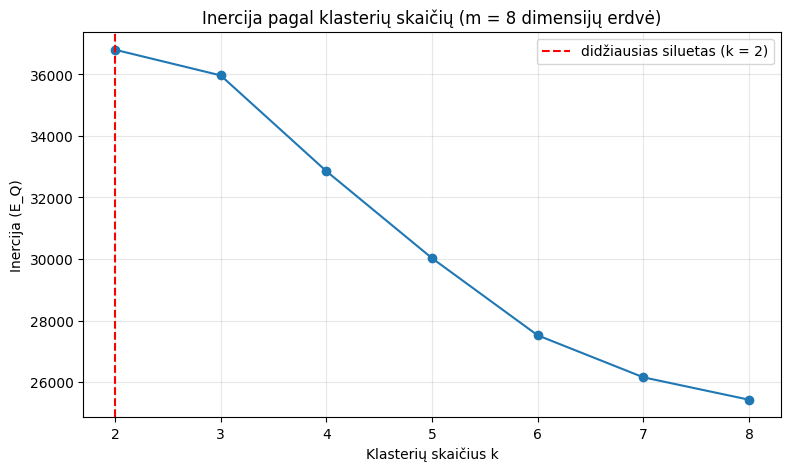

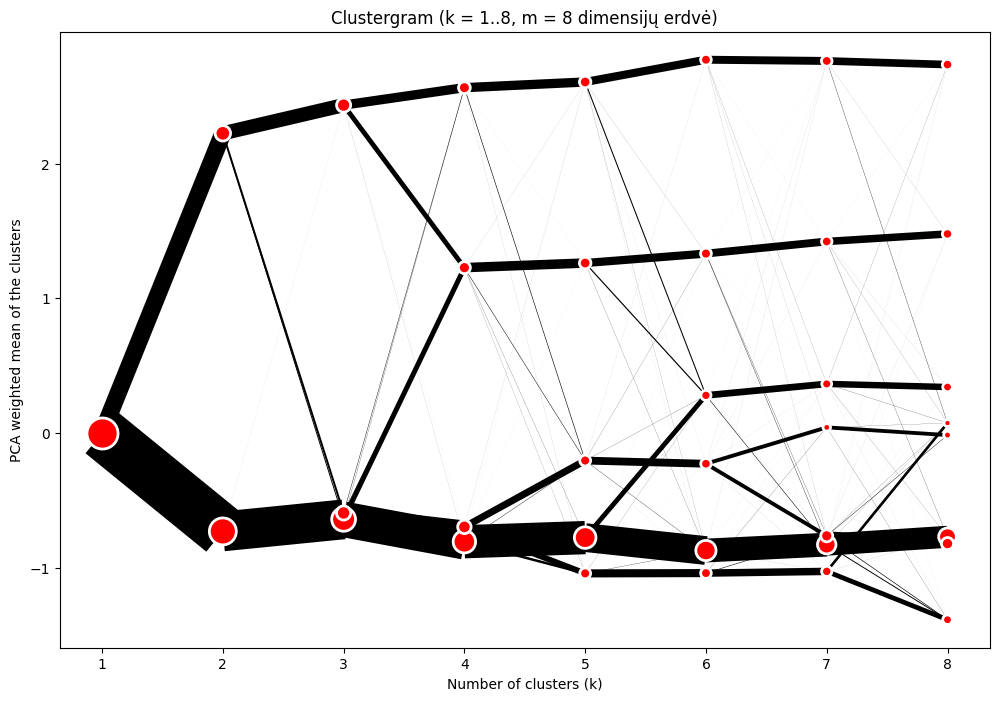

In [13]:
# ========== 5 uždavinio pabaiga: 3 silueto diagramos + inercijos grafikas + clustergram ==========

X = data_scaled.values                                   # m = 8 dimensijų erdvė
best_3_k = res_mdim.sort_values('silhouette', ascending=False).head(3)
best_k_list = best_3_k['k'].astype(int).tolist()         # 3 geriausi k pagal siluetą


# ---------- (A) 3 SILUETO DIAGRAMOS pagal 3 geriausius k ----------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, k in zip(axes, best_k_list):
    w, labels = SOM(X, k=k, n_iter=5000, random_state=42)
    sil_avg    = silhouette_score(X, labels, sample_size=1500, random_state=42)
    sample_sil = silhouette_samples(X, labels)
    y_lower = 10
    for cl in range(k):
        vals = np.sort(sample_sil[labels == cl])
        y_upper = y_lower + len(vals)
        color = plt.cm.nipy_spectral(float(cl) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(vals), str(cl))
        y_lower = y_upper + 10
    ax.axvline(sil_avg, color='red', linestyle='--', label=f'vidurkis = {sil_avg:.3f}')
    ax.set_title(f'Silueto diagrama, k = {k}')
    ax.set_xlabel('Silueto koeficiento vertė')
    ax.set_yticks([])
    ax.legend(fontsize=8)
plt.suptitle('3 geriausi k pagal silueto koeficientą (m = 8 dimensijų erdvė)', fontweight='bold')
plt.tight_layout()
plt.show()


# ---------- (B) INERCIJOS GRAFIKAS (OX = k, OY = inercija) ----------
plt.figure(figsize=(9, 5))
plt.plot(res_mdim['k'], res_mdim['inertia'], marker='o')
k_best_sil = int(res_mdim.loc[res_mdim['silhouette'].idxmax(), 'k'])
plt.axvline(k_best_sil, color='red', linestyle='--', label=f'didžiausias siluetas (k = {k_best_sil})')
plt.xlabel('Klasterių skaičius k')
plt.ylabel('Inercija (E_Q)')
plt.title('Inercija pagal klasterių skaičių (m = 8 dimensijų erdvė)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ---------- (C) KLASTERINĖ DIAGRAMA (Clustergram by M. Schonlau) ----------
cgram = Clustergram(range(1, 9), method='kmeans', n_init=10, random_state=42, verbose=False)
cgram.fit(X)                                             # X jau standartizuotas

ax = cgram.plot(figsize=(12, 8))
ax.yaxis.grid(False)
ax.set_title('Clustergram (k = 1..8, m = 8 dimensijų erdvė)')
plt.show()

# FUTURE: tegul sugeneruoja lenteles tokias, kokios yra ataskaitoj, kad butu galima copy paste

# FUTURE: reusable code

# FUTURE: perziureti ka claudeas pacookino del clustergram

Reikalaujama: lentelė + scatter grafikai + inercijos grafikai + silueto diagramos + clustergram. 

# https://www.geeksforgeeks.org/python/self-organising-maps-kohonen-maps/


Tinklelio struktūra -  1D tiesinė gardelė su k mazgų.

Svorių inicializacija - atsitiktinai parinktų elementų inicializacija

Atstumo formulė (BMU paieška) - Euklido atstumas

skaičiuojamas BMU kaimynystės spindulys. Šalia
neurono 𝑚𝑐 esantys neuronai vadinami pirmosios eilės kaimynai, paskui antrosios ir t. t. Iš pradžių spindulys būna didesnis, o paskui su kiekviena iteracija mažėja, naudojama formule: Kaimynystės funkcija - branduolys (8.16) [Gauso]

toliau kaimynai yra “apdovanojami”, Kuo viršūnė yra arčiau neurono 𝑚𝑐
, tuo labiau keičiami jos svoriai – tuo labiau “apdovanojami”. Tai reiškiasi, kad
ryšys yra stipresnis. naudojama formule (8.15)



mokymosi greitis - [0, 1]
Sustojimo sąlyga - epochs = [100,500] iterations= [1000,8000] 
Mc - BMU mazgas, inercija- ? nezinau kas tai, silueto koef - irgi nezinau

paklaida reikia skaiciuoti !!!!!!!!!!!!!!







Kas yra inercija? Suma kvadratinių atstumų nuo kiekvieno taško iki jo klasterio centro. SOM atveju centras = to taško BMU mazgo svorių vektorius — todėl inercija sutampa su kvantavimo paklaida $E_Q$ iš 11_SOM.pdf 10 skaidrės. Mažesnė inercija = tankesni klasteriai. Ji visada mažėja didinant k, todėl pati savaime „geriausio k" nepasako — bet braižant inercija vs k ieškoma „alkūnės" taško (kur kreivė staigiai išsilygina).

Kas yra silueto koeficientas? Matas, kaip gerai taškas „tinka" savo klasteryje: $s=(b-a)/\max(a,b)$, kur $a$ — vidutinis atstumas iki savo klasterio kaimynų, $b$ — iki artimiausio svetimo klasterio. $s\in[-1,1]$, didesnis = geriau atskirti klasteriai. Viso klasterizavimo siluetas = visų taškų $s$ vidurkis (silhouette_score). Šitą metriką ir naudoji rinkdamasis geriausią k bei geriausias atributų poras. Silueto diagramoms (3 uždavinys) naudosi silhouette_samples(X, labels) — gausi $s$ kiekvienam taškui atskirai.

Apie n_iter: užduočiai užtenka 5000 (konspektas mini „>1000 iteracijų"). Testuodamas gali sumažinti iki 1000, kad greičiau suktųsi; galutiniam rezultatui — 5000–8000.

Kitas žingsnis — ciklas per visas 28 poras × k=2..8, kuris pripildo lentelę ir išrenka 3 geriausias poras grafikams. Nori, kad ir tą parašyčiau?